# 02 — Reference Projection (R / Seurat CCA)

**Method:** Seurat Canonical Correlation Analysis (CCA) label transfer —
`FindTransferAnchors(reduction = 'cca')` + `TransferData` + `MapQuery`.

This is the **finalised pipeline method**, selected after benchmarking against scVI/scANVI
(see `benchmarking/benchmark_celltype.ipynb`).

**Seurat CCA workflow:**
1. Build reference atlas (PBMC3k annotated, 70% split)
2. `FindTransferAnchors` — identifies shared biological states via CCA
3. `TransferData` — transfers cell-type labels to query
4. `MapQuery` — projects query onto reference UMAP
5. Evaluate transfer accuracy (demo only — ground truth available from split)
6. Identify CD8+ T cells for downstream clonotype analysis

**Papermill parameters:** `reference_path`, `query_path`

In [1]:
# Papermill parameter cell
reference_path <- "../data/reference.rds"
query_path     <- "../data/query.rds"
output_path    <- "../data/query_projected.rds"
n_dims         <- 30L

In [2]:
# Parameters
reference_path = "data/reference.rds"
query_path = "data/query.rds"
output_path = "data/query_projected.rds"


In [3]:
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(patchwork)
  library(dplyr)
})
set.seed(42)
cat(sprintf("Seurat %s\n", packageVersion("Seurat")))

.nb02_start <- proc.time()[[3]]
cat(sprintf("NB02 started at %s\n", format(Sys.time(), "%H:%M:%S")))

Seurat 5.5.0


NB02 started at 19:33:22


## 1 · Build Reference Atlas

In production: load a pre-built pan-cancer TIL reference atlas (`.rds`).  
Here we split `pbmc3k.final` (pre-annotated) 70/30 to simulate a reference vs. new patient sample.

In [4]:
build_reference <- function() {
  stop("build_reference() should not be called — reference.rds is built by 00_data_acquisition.ipynb")
}

if (file.exists(reference_path) && file.exists(query_path)) {
  cat("Loading pre-built reference and query from disk...\n")
  ref   <- readRDS(reference_path)
  query <- readRDS(query_path)
} else {
  stop("reference.rds or query.rds not found — run 00_data_acquisition.ipynb first")
}

cat(sprintf("Reference: %d cells | Query: %d cells\n", ncol(ref), ncol(query)))

# Determine annotation column (NB00 uses 'cluster'; pbmc3k.final uses 'annotation_col')
if ("cluster" %in% colnames(ref@meta.data)) {
  annotation_col <- "cluster"
} else if (annotation_col %in% colnames(ref@meta.data)) {
  annotation_col <- annotation_col
} else {
  # fallback: use first character metadata column
  char_cols <- names(Filter(is.character, as.data.frame(ref@meta.data)))
  annotation_col <- char_cols[1]
  warning(sprintf("No standard annotation column found; using '%s'", annotation_col))
}
cat(sprintf("Using '%s' as reference annotation column\n", annotation_col))
cat("Reference cell types:\n")
print(table(ref@meta.data[[annotation_col]]))


Loading pre-built reference and query from disk...


Reference: 32531 cells | Query: 30683 cells


Using 'cluster' as reference annotation column


Reference cell types:



   CD8_act    CD8_eff     CD8_ex CD8_ex_act    CD8_mem      Naive        Tfh 
      3874        775       1252        302       6096       5163       2778 
      Th17      Tregs 
      7851       4440 


## 2 · Prepare Reference

Ensure the reference has PCA computed and UMAP fit with `return.model = TRUE` (required by `MapQuery`).

Running PCA + neighbours + UMAP on reference...


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


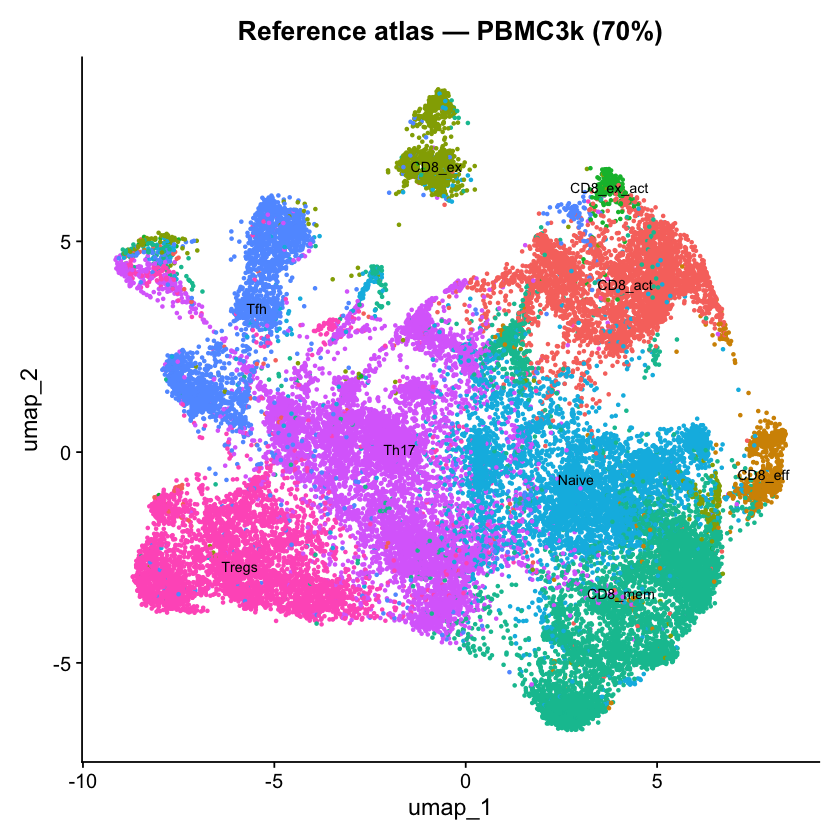

In [5]:
# Re-run UMAP with return.model = TRUE if not already present
if (!"model" %in% names(ref@reductions$umap)) {
  cat("Running PCA + neighbours + UMAP on reference...\n")
  # If PCA not available, recompute
  if (!"pca" %in% names(ref@reductions)) {
    ref <- FindVariableFeatures(ref, nfeatures = 2000, verbose = FALSE)
    ref <- ScaleData(ref, features = VariableFeatures(ref), verbose = FALSE)
    ref <- RunPCA(ref, npcs = 50, verbose = FALSE)
  }
  ref <- FindNeighbors(ref, dims = 1:n_dims, verbose = FALSE)
  ref <- RunUMAP(ref, dims = 1:n_dims, return.model = TRUE, verbose = FALSE)
} else {
  cat("Reference already has UMAP model — reusing\n")
}

DimPlot(ref, reduction = "umap", group.by = annotation_col,
        label = TRUE, label.size = 3, pt.size = 0.5) +
  ggtitle("Reference atlas — PBMC3k (70%)") + NoLegend()

## 3 · Find CCA Transfer Anchors

`FindTransferAnchors(reduction = 'cca')` identifies shared biological variation between reference and query by projecting both datasets into a common CCA space. Anchor pairs are high-confidence cell correspondences.

This mirrors Seurat's original CCA integration described in Stuart et al., Cell 2019.

In [6]:
cat("Finding CCA transfer anchors...\n")
.anchors_start <- proc.time()[[3]]
anchors <- FindTransferAnchors(
  reference  = ref,
  query      = query,
  dims       = 1:n_dims,
  reduction           = "pcaproject", # PCA projection — O(n), much less memory than CCA
  reference.reduction = "pca",             # required for MapQuery
  verbose             = FALSE,
  approx.pca          = TRUE
)
cat(sprintf("Found %d anchors\n", nrow(anchors@anchors)))
.anchors_elapsed <- proc.time()[[3]] - .anchors_start
cat(sprintf("FindTransferAnchors elapsed: %.1f s (%.1f min)\n", .anchors_elapsed, .anchors_elapsed / 60))

Finding CCA transfer anchors...


Found 80732 anchors


FindTransferAnchors elapsed: 37.2 s (0.6 min)


## 4 · Transfer Cell-type Labels

`TransferData` uses the CCA anchors to compute a weighted prediction score for each cell-type label.

Finding integration vectors



Finding integration vector weights



Predicting cell labels



Transferred label distribution (query):



   CD8_act    CD8_eff     CD8_ex CD8_ex_act    CD8_mem      Naive        Tfh 
      3650        713       1155        283       5790       4859       2558 
      Th17      Tregs 
      7585       4090 


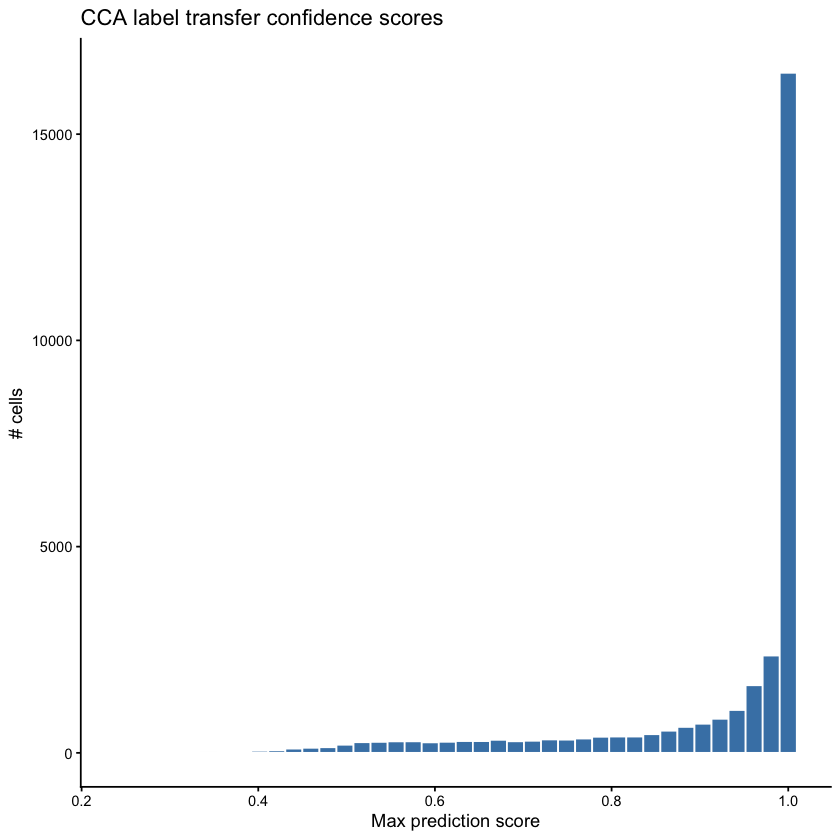

In [7]:
predictions <- TransferData(
  anchorset        = anchors,
  refdata          = ref@meta.data[[annotation_col]],
  dims      = 1:n_dims
)
query <- AddMetaData(query, metadata = predictions)

cat("Transferred label distribution (query):\n")
print(table(query$predicted.id))

# Prediction score distribution
ggplot(query@meta.data, aes(x = prediction.score.max)) +
  geom_histogram(bins = 40, fill = "steelblue", colour = "white") +
  labs(x = "Max prediction score", y = "# cells",
       title = "CCA label transfer confidence scores") +
  theme_classic()

## 5 · MapQuery — Project onto Reference UMAP

`MapQuery` combines label transfer and dimensional reduction mapping, placing query cells into the reference UMAP space.

In [8]:
query <- MapQuery(
  anchorset         = anchors,
  reference         = ref,
  query             = query,
  refdata           = list(celltype = annotation_col),
  reference.reduction = "pca",
  reduction.model   = "umap"
)

cat("Query embeddings after MapQuery:\n")
print(names(query@reductions))

Finding integration vectors



Finding integration vector weights



Predicting cell labels



Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Warning message:
“Layer counts isn't present in the assay object; returning NULL”


...

19:35:15 Initializing by weighted average of neighbor coordinates using 1 thread



19:35:15 Commencing optimization for 67 epochs, with 920490 positive edges



19:35:18 Finished



Query embeddings after MapQuery:


[1] "pca"      "umap"     "ref.pca"  "ref.umap"


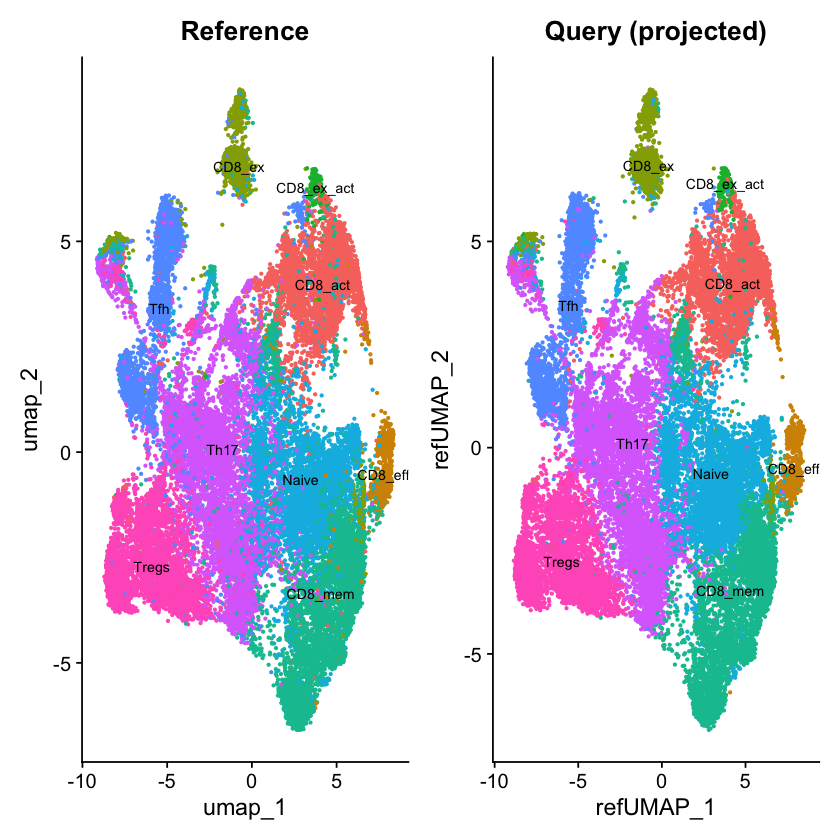

In [9]:
# Joint UMAP visualisation
ref$origin   <- "reference"
query$origin <- "query"

# Use ref.umap embedding to place both datasets
p_ref <- DimPlot(ref, reduction = "umap", group.by = annotation_col,
                 label = TRUE, label.size = 3, pt.size = 0.4) +
         NoLegend() + ggtitle("Reference")

p_qry <- DimPlot(query, reduction = "ref.umap", group.by = "predicted.id",
                 label = TRUE, label.size = 3, pt.size = 0.4) +
         NoLegend() + ggtitle("Query (projected)")

p_ref + p_qry

## 6 · Evaluate Label Transfer

Since we have ground-truth labels for the demo split, we can evaluate transfer accuracy.

In [10]:
if ("celltype_true" %in% colnames(query@meta.data)) {
  conf <- table(
    Predicted = query$predicted.id,
    True      = query$celltype_true
  )
  cat("=== Confusion matrix (predicted rows, true columns) ===\n")
  print(conf)

  # Per-class accuracy
  acc <- sum(diag(conf)) / sum(conf)
  cat(sprintf("\nOverall label transfer accuracy: %.1f%%\n", acc * 100))

  # Visualise as heatmap
  conf_df <- as.data.frame(conf)
  ggplot(conf_df, aes(x = True, y = Predicted, fill = Freq)) +
    geom_tile() +
    geom_text(aes(label = Freq), size = 3) +
    scale_fill_gradient(low = "white", high = "steelblue") +
    theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = "CCA label transfer — confusion matrix",
         x = "True cell type", y = "Predicted cell type")
} else {
  cat("No ground-truth labels available for evaluation.\n")
}

No ground-truth labels available for evaluation.


## 7 · Identify CD8+ T Cells

CD8+ T cells in query: 11591 / 30683 (37.8%)


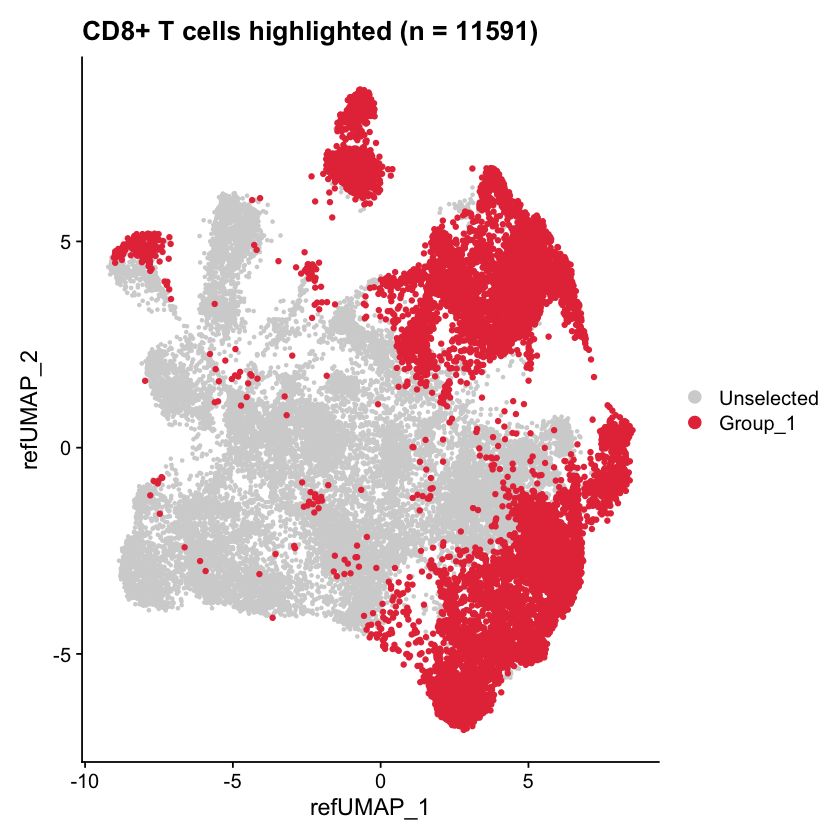

In [11]:
query$is_cd8 <- grepl("CD8", query$predicted.id, ignore.case = TRUE)
n_cd8 <- sum(query$is_cd8)
cat(sprintf("CD8+ T cells in query: %d / %d (%.1f%%)\n",
            n_cd8, ncol(query), n_cd8 / ncol(query) * 100))

DimPlot(query, reduction = "ref.umap",
        cells.highlight = colnames(query)[query$is_cd8],
        cols.highlight = "#e63946", cols = "lightgrey",
        pt.size = 0.5) +
  ggtitle(sprintf("CD8+ T cells highlighted (n = %d)", n_cd8))

## 8 · Save Projected Query

In [12]:
saveRDS(query, file = output_path)
cat(sprintf("Saved projected Seurat object → %s\n", output_path))
cat(sprintf("Key metadata columns: %s\n",
            paste(colnames(query@meta.data), collapse = ", ")))

.nb02_elapsed <- proc.time()[[3]] - .nb02_start
cat(sprintf("\n=== NB02 Timing Summary ===\n"))
cat(sprintf("  FindTransferAnchors : %6.1f s (%5.1f min)\n", .anchors_elapsed, .anchors_elapsed / 60))
cat(sprintf("  Total NB02 elapsed  : %6.1f s (%5.1f min)\n", .nb02_elapsed, .nb02_elapsed / 60))

Saved projected Seurat object → data/query_projected.rds


Key metadata columns: orig.ident, nCount_RNA, nFeature_RNA, patient, treatment, cluster, UMAP1, UMAP2, clonotype_id, has_tcr, percent.mt, RNA_snn_res.0.5, seurat_clusters, doublet_score, predicted_doublet, predicted.id, prediction.score.CD8_mem, prediction.score.Th17, prediction.score.Tregs, prediction.score.CD8_act, prediction.score.Naive, prediction.score.Tfh, prediction.score.CD8_eff, prediction.score.CD8_ex, prediction.score.CD8_ex_act, prediction.score.max, predicted.celltype.score, predicted.celltype, origin, is_cd8



=== NB02 Timing Summary ===


  FindTransferAnchors :   37.2 s (  0.6 min)


  Total NB02 elapsed  :  175.5 s (  2.9 min)
